In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from numpy import pi, random

In [2]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

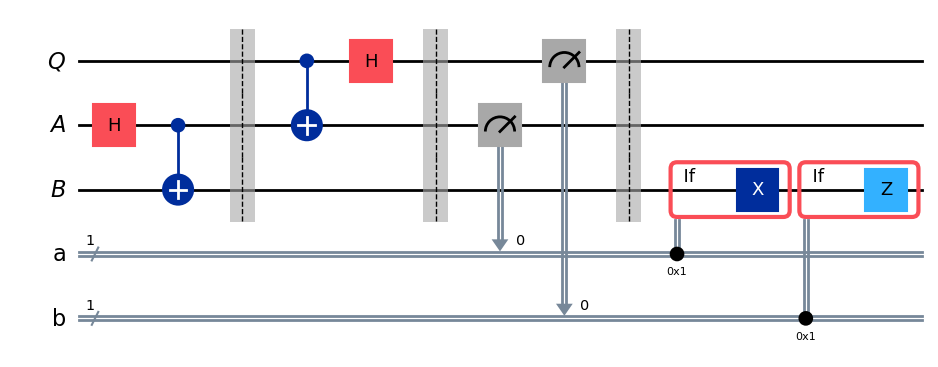

In [3]:
# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw(output='mpl'))

In [4]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(random_gate.to_matrix())

array([[ 0.32582959+0.j        ,  0.91481989-0.23862029j],
       [-0.26645077+0.90710477j,  0.00995198-0.32567757j]])

In [5]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.
test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Start with the randomly selected gate on Q
test.append(random_gate, qubit)
test.barrier()

# Append the entire teleportation protocol from above.
test = test.compose(protocol)
test.barrier()

# Finally, apply the inverse of the random unitary to B and measure.
test.append(random_gate.inverse(), ebit1)

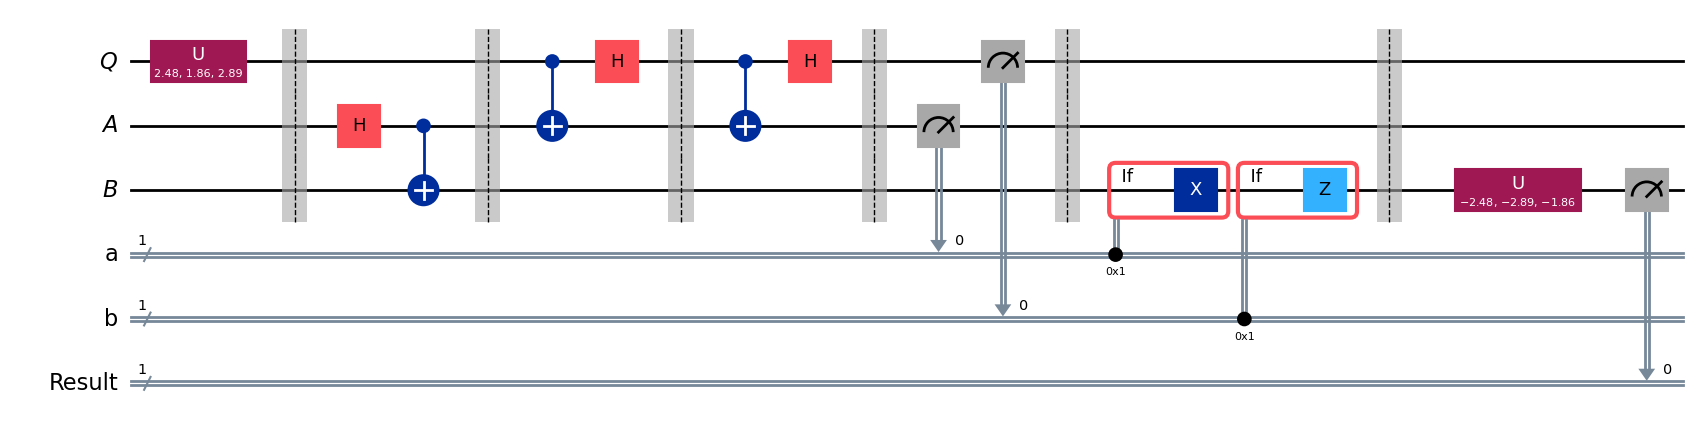

In [6]:
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw(output='mpl'))

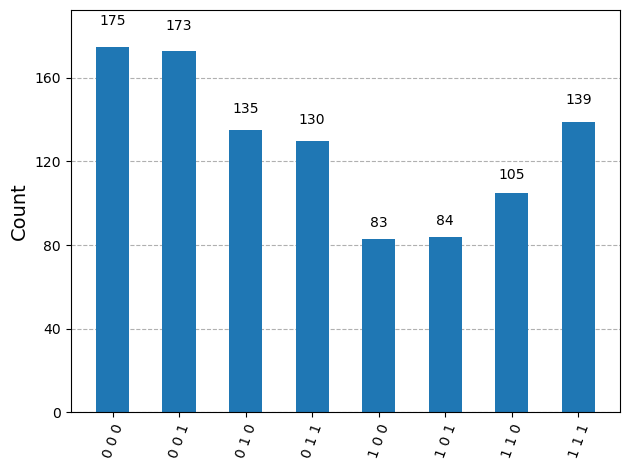

In [7]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

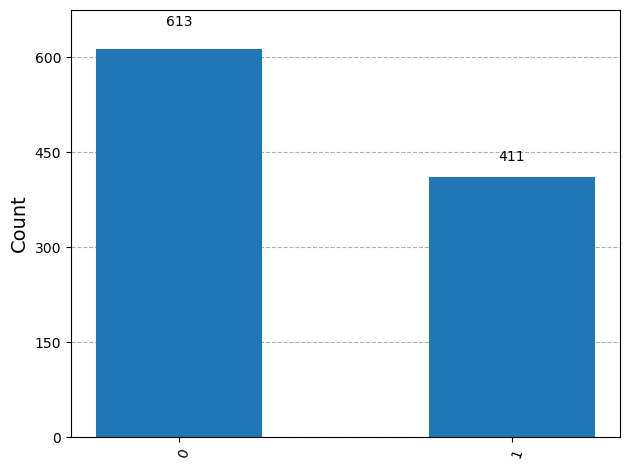

In [8]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

In [12]:
# teleportation_test_if_test.py
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UGate
from qiskit_aer import AerSimulator
import numpy as np

def random_single_qubit_gate():
    """Generate a random single-qubit unitary gate."""
    theta = np.random.random() * 2 * np.pi
    phi = np.random.random() * 2 * np.pi
    lam = np.random.random() * 2 * np.pi
    return UGate(theta, phi, lam)

def make_teleportation_circuit(random_gate):
    """Constructs a teleportation circuit that teleports a random single-qubit state."""
    Q = QuantumRegister(1, 'Q')   # State to teleport
    A = QuantumRegister(1, 'A')   # Alice's half of entangled pair
    B = QuantumRegister(1, 'B')   # Bob's half of entangled pair
    cA = ClassicalRegister(1, 'cA')
    cQ = ClassicalRegister(1, 'cQ')
    out = ClassicalRegister(1, 'out')  # Result bit after inverse
    qc = QuantumCircuit(Q, A, B, cA, cQ, out)

    # 1) Prepare random state on Q
    qc.append(random_gate, [Q[0]])
    qc.barrier()

    # 2) Create Bell pair between A and B
    qc.h(A[0])
    qc.cx(A[0], B[0])
    qc.barrier()

    # 3) Alice's Bell measurement
    qc.cx(Q[0], A[0])
    qc.h(Q[0])
    qc.barrier()

    # 4) Measure Alice's qubits
    qc.measure(A[0], cA[0])
    qc.measure(Q[0], cQ[0])
    qc.barrier()

    # 5) Bob applies corrections using classical flow (if_test)
    # If cA == 1 -> apply X on B
    with qc.if_test((cA, 1)):
        qc.x(B[0])
    # If cQ == 1 -> apply Z on B
    with qc.if_test((cQ, 1)):
        qc.z(B[0])
    qc.barrier()

    # 6) Apply inverse of random gate and measure Bob
    qc.append(random_gate.inverse(), [B[0]])
    qc.measure(B[0], out[0])

    return qc

def test_many_random_states(N=10, shots=1024):
    """Run teleportation test for multiple random single-qubit states."""
    backend = AerSimulator()
    total_success = 0

    for i in range(N):
        U = random_single_qubit_gate()
        qc = make_teleportation_circuit(U)
        t_qc = transpile(qc, backend)
        job = backend.run(t_qc, shots=shots)
        res = job.result()
        counts = res.get_counts()

        # Count how many results have Bob’s final bit = 0
        out_zero_counts = 0
        total_counts = 0
        for bitstr, cnt in counts.items():
            # 'out' is the last classical register, so check last character
            if bitstr[-1] == '0':
                out_zero_counts += cnt
            total_counts += cnt

        success_rate = out_zero_counts / total_counts
        print(f"Test {i+1}/{N}: Success rate = {success_rate:.6f}")
        total_success += success_rate

    avg_success = total_success / N
    print(f"\nAverage success rate over {N} random states: {avg_success:.6f}")
    return avg_success

if __name__ == "__main__":
    test_many_random_states(N=10, shots=1024)


Test 1/10: Success rate = 0.487305
Test 2/10: Success rate = 0.497070
Test 3/10: Success rate = 0.474609
Test 4/10: Success rate = 0.499023
Test 5/10: Success rate = 0.507812
Test 6/10: Success rate = 0.518555
Test 7/10: Success rate = 0.496094
Test 8/10: Success rate = 0.510742
Test 9/10: Success rate = 0.500977
Test 10/10: Success rate = 0.506836

Average success rate over 10 random states: 0.499902



================= Test 1/5 =================
Random single-qubit gate matrix:
 [[-0.545+0.j     0.366-0.754j]
 [ 0.778+0.314j  0.404-0.366j]]
Initial quantum state of Q (|ψ⟩ = U|0⟩):
 [[-0.545+0.j   ]
 [ 0.778+0.314j]]

--- Quantum Teleportation Circuit (with barriers) ---


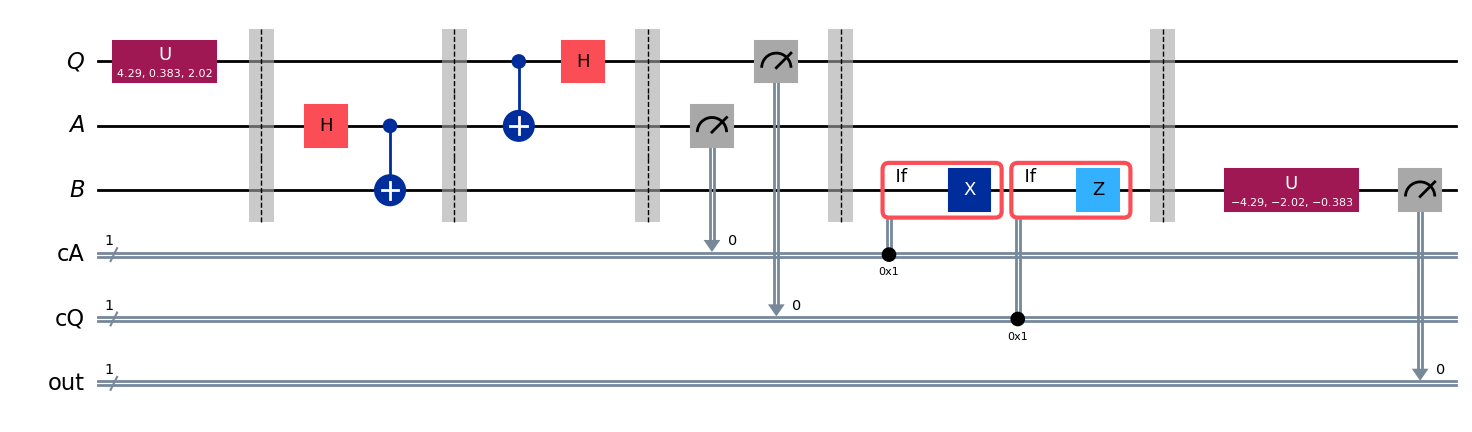

Measurement results (bitstring: count):
 {'0 0 1': 267, '0 0 0': 276, '0 1 0': 244, '0 1 1': 237}
Teleportation success probability (B measured |0⟩): 0.5078


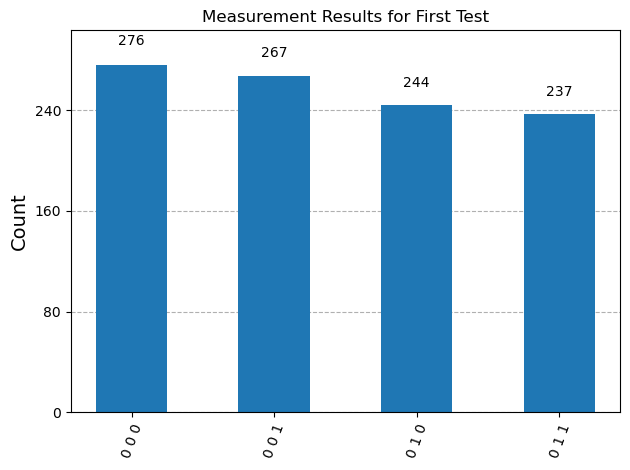


================= Test 2/5 =================
Random single-qubit gate matrix:
 [[ 0.358+0.j     0.357+0.863j]
 [ 0.236-0.903j -0.355+0.048j]]
Initial quantum state of Q (|ψ⟩ = U|0⟩):
 [[0.358+0.j   ]
 [0.236-0.903j]]
Measurement results (bitstring: count):
 {'0 0 0': 282, '0 1 0': 256, '0 1 1': 266, '0 0 1': 220}
Teleportation success probability (B measured |0⟩): 0.5254

================= Test 3/5 =================
Random single-qubit gate matrix:
 [[ 0.966+0.j     0.256+0.028j]
 [ 0.198-0.166j -0.804+0.536j]]
Initial quantum state of Q (|ψ⟩ = U|0⟩):
 [[0.966+0.j   ]
 [0.198-0.166j]]
Measurement results (bitstring: count):
 {'0 0 1': 256, '0 1 0': 233, '0 1 1': 249, '0 0 0': 286}
Teleportation success probability (B measured |0⟩): 0.5068

================= Test 4/5 =================
Random single-qubit gate matrix:
 [[-0.779+0.j     0.327+0.534j]
 [-0.241+0.578j -0.77 +0.12j ]]
Initial quantum state of Q (|ψ⟩ = U|0⟩):
 [[-0.779+0.j   ]
 [-0.241+0.578j]]
Measurement results (bitstring

In [13]:
# teleportation_full_output.py
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UGate
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.visualization import plot_histogram

def random_single_qubit_gate():
    """Generate a random single-qubit unitary gate."""
    theta = np.random.random() * 2 * np.pi
    phi = np.random.random() * 2 * np.pi
    lam = np.random.random() * 2 * np.pi
    return UGate(theta, phi, lam)

def make_teleportation_circuit(random_gate):
    """Constructs a teleportation circuit that teleports a random single-qubit state."""
    Q = QuantumRegister(1, 'Q')   # State to teleport
    A = QuantumRegister(1, 'A')   # Alice's half of entangled pair
    B = QuantumRegister(1, 'B')   # Bob's half of entangled pair
    cA = ClassicalRegister(1, 'cA')
    cQ = ClassicalRegister(1, 'cQ')
    out = ClassicalRegister(1, 'out')  # Result bit after inverse
    qc = QuantumCircuit(Q, A, B, cA, cQ, out)

    # (1) Prepare random state on Q
    qc.append(random_gate, [Q[0]])
    qc.barrier()

    # (2) Create Bell pair between A and B
    qc.h(A[0])
    qc.cx(A[0], B[0])
    qc.barrier()

    # (3) Alice's Bell measurement
    qc.cx(Q[0], A[0])
    qc.h(Q[0])
    qc.barrier()

    # (4) Measure Alice’s qubits
    qc.measure(A[0], cA[0])
    qc.measure(Q[0], cQ[0])
    qc.barrier()

    # (5) Bob’s conditional corrections
    with qc.if_test((cA, 1)):
        qc.x(B[0])
    with qc.if_test((cQ, 1)):
        qc.z(B[0])
    qc.barrier()

    # (6) Apply inverse of random gate and measure Bob
    qc.append(random_gate.inverse(), [B[0]])
    qc.measure(B[0], out[0])

    return qc

def test_many_random_states(N=5, shots=1024):
    """Run teleportation test for multiple random single-qubit states."""
    backend = AerSimulator()
    total_success = 0

    for i in range(N):
        print(f"\n================= Test {i+1}/{N} =================")
        U = random_single_qubit_gate()
        print("Random single-qubit gate matrix:\n", np.round(U.to_matrix(), 3))
        
        # Theoretical initial state of Q after applying U to |0>
        initial_state = U.to_matrix() @ np.array([[1], [0]])
        print("Initial quantum state of Q (|ψ⟩ = U|0⟩):\n", np.round(initial_state, 3))
        
        qc = make_teleportation_circuit(U)

        if i == 0:
            print("\n--- Quantum Teleportation Circuit (with barriers) ---")
            display(qc.draw(output="mpl"))  # Show circuit only for the first test

        t_qc = transpile(qc, backend)
        job = backend.run(t_qc, shots=shots)
        res = job.result()
        counts = res.get_counts()

        # Count how many results have Bob’s final bit = 0
        out_zero_counts = 0
        total_counts = 0
        for bitstr, cnt in counts.items():
            # 'out' is last classical register, so last bit of string
            if bitstr[-1] == '0':
                out_zero_counts += cnt
            total_counts += cnt

        success_rate = out_zero_counts / total_counts
        print("Measurement results (bitstring: count):\n", counts)
        print(f"Teleportation success probability (B measured |0⟩): {success_rate:.4f}")
        total_success += success_rate

        if i == 0:
            display(plot_histogram(counts, title="Measurement Results for First Test"))

    avg_success = total_success / N
    print(f"\n================= Summary =================")
    print(f"Average teleportation success rate over {N} random states: {avg_success:.4f}")
    if avg_success > 0.99:
        print("✅ Proof: Quantum state |ψ⟩ was successfully teleported to qubit B.")
    else:
        print("⚠️ Teleportation not perfect — check simulator noise or classical control.")

# Run all 4 tasks
if __name__ == "__main__":
    test_many_random_states(N=5, shots=1024)



Test 1/5
Random gate U matrix:
 [[ 0.7514+0.j      0.5499+0.3646j]
 [-0.4847-0.4476j  0.1783+0.73j  ]]
Initial state |ψ⟩ = U|0⟩ (vector):
 [ 0.7514+0.j     -0.4847-0.4476j]

--- Exact (statevector) proof ---
 Branch a=0 q=0: prob=0.28233248, F_branch=0.13576759, weighted=0.0383316
 Branch a=0 q=1: prob=0.21766752, F_branch=0.13576759, weighted=0.02955219
 Branch a=1 q=0: prob=0.21766752, F_branch=0.86423241, weighted=0.18811533
 Branch a=1 q=1: prob=0.28233248, F_branch=0.86423241, weighted=0.24400088
 => Weighted fidelity (sum_p F): 0.5

--- Teleportation circuit (first test) ---


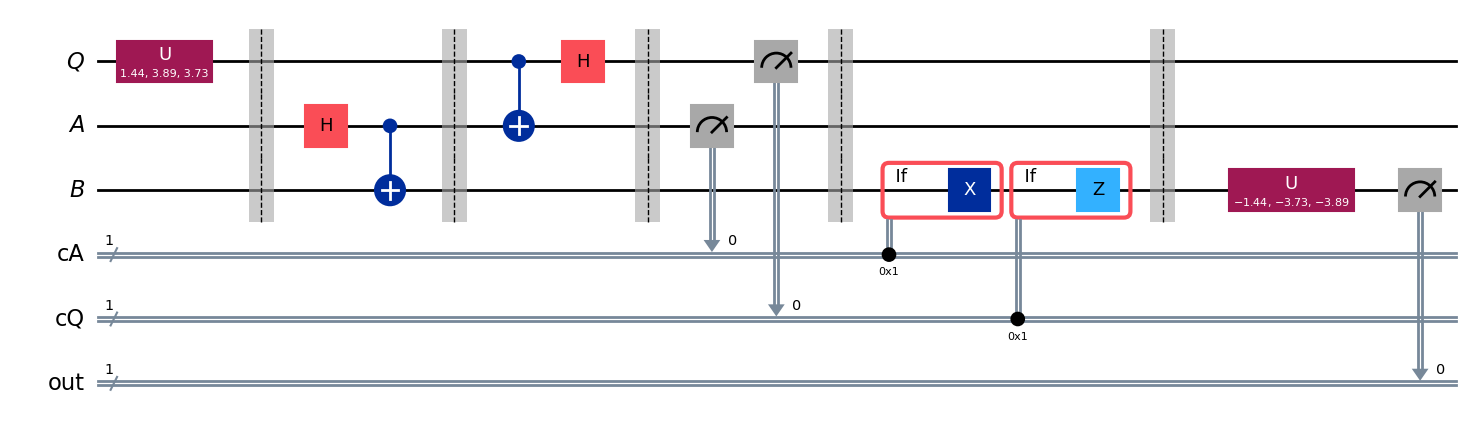


--- Shot-based (measurement) results ---
Counts: {'0 1 0': 493, '0 0 0': 524, '0 1 1': 500, '0 0 1': 531}
Measured fraction of B==|0> after U† (should be ~1): 0.496582


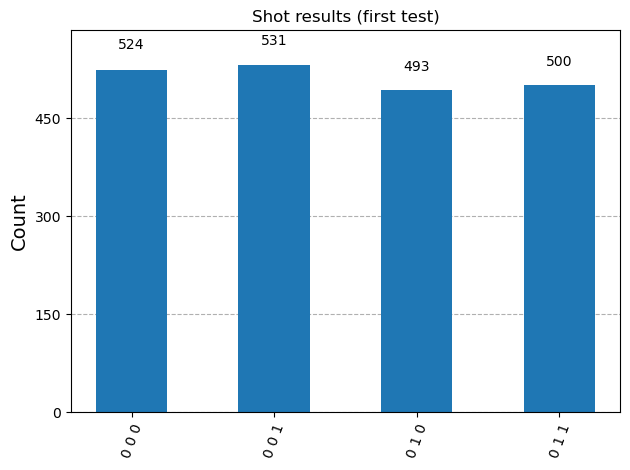


Test 2/5
Random gate U matrix:
 [[-0.4447+0.j      0.796 -0.4106j]
 [-0.5019+0.7419j -0.0526+0.4415j]]
Initial state |ψ⟩ = U|0⟩ (vector):
 [-0.4447+0.j     -0.5019+0.7419j]

--- Exact (statevector) proof ---
 Branch a=0 q=0: prob=0.09885839, F_branch=0.72316528, weighted=0.07149096
 Branch a=0 q=1: prob=0.40114161, F_branch=0.72316528, weighted=0.29009168
 Branch a=1 q=0: prob=0.40114161, F_branch=0.27683472, weighted=0.11104993
 Branch a=1 q=1: prob=0.09885839, F_branch=0.27683472, weighted=0.02736744
 => Weighted fidelity (sum_p F): 0.5

--- Shot-based (measurement) results ---
Counts: {'0 1 1': 503, '0 1 0': 535, '0 0 0': 486, '0 0 1': 524}
Measured fraction of B==|0> after U† (should be ~1): 0.498535

Test 3/5
Random gate U matrix:
 [[ 0.3237+0.j      0.9066-0.2708j]
 [ 0.2173+0.9209j -0.1614-0.2806j]]
Initial state |ψ⟩ = U|0⟩ (vector):
 [0.3237+0.j     0.2173+0.9209j]

--- Exact (statevector) proof ---
 Branch a=0 q=0: prob=0.05239677, F_branch=0.57033602, weighted=0.02988377
 Br

In [14]:
# teleportation_proof.py
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

# -------------------------
# Utilities
# -------------------------
def random_single_qubit_gate():
    theta = np.random.random() * 2 * np.pi
    phi   = np.random.random() * 2 * np.pi
    lam   = np.random.random() * 2 * np.pi
    return UGate(theta, phi, lam)

X = np.array([[0,1],[1,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

def index_from_bits(q_bit, a_bit, b_bit):
    """Map bits (q,a,b) to integer index assuming ordering [Q, A, B],
       index = q*4 + a*2 + b (i.e. Q is most-significant bit)."""
    return (q_bit << 2) | (a_bit << 1) | b_bit

# -------------------------
# Build circuits
# -------------------------
def teleportation_circuit_no_measure(U):
    """Circuit that prepares U|0> on Q, creates Bell pair A-B, 
       and performs Alice's Bell measurement operations but does NOT measure.
       Registers order: Q, A, B.
    """
    Q = QuantumRegister(1, 'Q')
    A = QuantumRegister(1, 'A')
    B = QuantumRegister(1, 'B')
    qc = QuantumCircuit(Q, A, B)

    # Prepare arbitrary state on Q
    qc.append(U, [Q[0]])
    qc.barrier()

    # Bell pair between A and B
    qc.h(A[0])
    qc.cx(A[0], B[0])
    qc.barrier()

    # Alice's Bell measurement (operations only)
    qc.cx(Q[0], A[0])
    qc.h(Q[0])
    qc.barrier()

    return qc

def teleportation_circuit_full(U):
    """Full circuit including measurements, corrections (via if_test), U† on B, and measurement of B's final bit.
       This one is for the shot-based experimental test.
    """
    Q = QuantumRegister(1, 'Q')
    A = QuantumRegister(1, 'A')
    B = QuantumRegister(1, 'B')
    cA = ClassicalRegister(1, 'cA')
    cQ = ClassicalRegister(1, 'cQ')
    out = ClassicalRegister(1, 'out')
    qc = QuantumCircuit(Q, A, B, cA, cQ, out)

    qc.append(U, [Q[0]]); qc.barrier()
    qc.h(A[0]); qc.cx(A[0], B[0]); qc.barrier()
    qc.cx(Q[0], A[0]); qc.h(Q[0]); qc.barrier()
    qc.measure(A[0], cA[0])
    qc.measure(Q[0], cQ[0]); qc.barrier()
    # classical flow corrections
    with qc.if_test((cA, 1)):
        qc.x(B[0])
    with qc.if_test((cQ, 1)):
        qc.z(B[0])
    qc.barrier()
    # apply inverse of U and measure B
    qc.append(U.inverse(), [B[0]])
    qc.measure(B[0], out[0])

    return qc

# -------------------------
# Exact/statevector proof
# -------------------------
def exact_teleportation_fidelity(U):
    """
    Perform a statevector-based exact proof of teleportation fidelity.
    Steps:
    - Build circuit up to Alice's measurement (no classical measurement).
    - Get full 3-qubit statevector (ordering Q,A,B).
    - For each outcome (a, q) in {0,1}^2:
        * extract branch amplitude vector for Bob (b = 0,1)
        * compute branch probability p_branch
        * normalize branch Bob state to get |phi_branch>
        * apply classical corrections to Bob: if a==1 apply X, if q==1 apply Z (order: X then Z)
        * compute fidelity F_branch = |<psi | phi_corrected>|^2
    - Return weighted fidelity sum(sum p_branch * F_branch) and per-branch details.
    """
    # 1) original state |psi> = U |0>
    psi = (U.to_matrix() @ np.array([[1.0],[0.0]], dtype=complex)).reshape((2,))

    # 2) get full 3-qubit statevector after Alice's ops (but before measurement)
    qc_no_meas = teleportation_circuit_no_measure(U)
    sv = Statevector.from_instruction(qc_no_meas)  # length 8 vector; ordering [Q,A,B]
    amps = sv.data  # numpy array length 8

    # prepare storage
    branch_info = []
    fidelity_weighted_sum = 0.0

    # iterate measurement outcomes: a in {0,1}, q in {0,1}
    for a in (0,1):
        for q in (0,1):
            # pick amplitudes where Q==q and A==a, b runs over 0,1
            # idx = q*4 + a*2 + b
            amp_b0 = amps[index_from_bits(q, a, 0)]
            amp_b1 = amps[index_from_bits(q, a, 1)]
            branch_prob = (abs(amp_b0)**2 + abs(amp_b1)**2).real

            if branch_prob == 0:
                # impossible branch
                phi = np.array([0+0j, 0+0j])
                F_branch = 0.0
            else:
                # unnormalized bob vector for this branch:
                bob_unnorm = np.array([amp_b0, amp_b1], dtype=complex)
                # normalize to get phi (Bob's state before corrections)
                phi = bob_unnorm / np.sqrt(branch_prob)

                # Apply classical corrections:
                # If a == 1 -> apply X
                # If q == 1 -> apply Z
                # Order: X then Z (same as circuit)
                phi_corrected = phi.copy()
                if a == 1:
                    phi_corrected = X @ phi_corrected
                if q == 1:
                    phi_corrected = Z @ phi_corrected

                # Fidelity between |psi> and |phi_corrected> is |<psi|phi_corrected>|^2
                overlap = np.vdot(psi, phi_corrected)  # <psi|phi_corrected>
                F_branch = (abs(overlap)**2).real

            fidelity_weighted_sum += branch_prob * F_branch
            branch_info.append({
                'a': a,
                'q': q,
                'branch_prob': float(np.round(branch_prob, 8)),
                'F_branch': float(np.round(F_branch, 8)),
                'weighted': float(np.round(branch_prob * F_branch, 8)),
            })

    return {
        'psi': psi,
        'branch_info': branch_info,
        'weighted_fidelity': float(np.round(fidelity_weighted_sum, 12))
    }

# -------------------------
# Combined test & outputs
# -------------------------
def run_full_tests(num_tests=5, shots=2048):
    backend = AerSimulator()
    avg_shot_success = 0.0
    avg_exact_fidelity = 0.0

    for t in range(num_tests):
        print("\n" + "="*60)
        print(f"Test {t+1}/{num_tests}")
        U = random_single_qubit_gate()
        psi = (U.to_matrix() @ np.array([[1.0],[0.0]], dtype=complex)).reshape((2,))
        print("Random gate U matrix:\n", np.round(U.to_matrix(), 4))
        print("Initial state |ψ⟩ = U|0⟩ (vector):\n", np.round(psi, 4))

        # ---- Exact/statevector proof ----
        exact = exact_teleportation_fidelity(U)
        print("\n--- Exact (statevector) proof ---")
        for info in exact['branch_info']:
            print(f" Branch a={info['a']} q={info['q']}: prob={info['branch_prob']}, "
                  f"F_branch={info['F_branch']}, weighted={info['weighted']}")
        print(f" => Weighted fidelity (sum_p F): {exact['weighted_fidelity']}")
        avg_exact_fidelity += exact['weighted_fidelity']

        # ---- Shot-based experimental proof ----
        qc_full = teleportation_circuit_full(U)
        # Show circuit only for first test
        if t == 0:
            print("\n--- Teleportation circuit (first test) ---")
            display(qc_full.draw(output='mpl'))

        t_qc = transpile(qc_full, backend)
        job = backend.run(t_qc, shots=shots)
        res = job.result()
        counts = res.get_counts()
        # out bit is the last classical bit; count zero outcomes
        out_zero = sum(cnt for bitstr, cnt in counts.items() if bitstr[-1] == '0')
        total = sum(counts.values())
        shot_success = out_zero / total
        avg_shot_success += shot_success

        print("\n--- Shot-based (measurement) results ---")
        print("Counts:", counts)
        print(f"Measured fraction of B==|0> after U† (should be ~1): {shot_success:.6f}")

        # Optionally display histogram for the first test
        if t == 0:
            display(plot_histogram(counts, title="Shot results (first test)"))

    avg_exact_fidelity /= num_tests
    avg_shot_success /= num_tests
    print("\n" + "="*60)
    print("Summary over tests:")
    print(f"Average exact weighted fidelity  (statevector proof): {avg_exact_fidelity:.12f}")
    print(f"Average shot-based success rate (U† + measure): {avg_shot_success:.6f}")

    # formal decision
    if avg_exact_fidelity > 0.9999:
        print("✅ Exact proof: Teleportation fidelity ≈ 1. Q was successfully teleported to B.")
    else:
        print("⚠️ Exact proof indicates lower fidelity; check implementation/simulator.")

# -------------------------
# Entry point
# -------------------------
if __name__ == "__main__":
    run_full_tests(num_tests=5, shots=2048)
